# EDA por cultivo — correlaciones exploratorias

Análisis **exploratorio** sobre `dataset_integrado.csv` (Pareto-80, mapping v2).

**Limitaciones explícitas:**
- Correlación ≠ causalidad; sin desestacionalización ni corrección por comparaciones múltiples.
- Cultivos del mismo (región, piso) comparten clima idéntico.
- Producción en toneladas (volumen), no rendimiento t/ha.

**Unidades:** `radiacion_solar` en MJ/m²/día; `humedad_especifica` en kg/kg; `precipitacion` en mm/día.

### Qué hace esta celda

Setup: carga `dataset_integrado.csv` (granularidad cultivo×mes), define rutas y variables climáticas para el Análisis B (correlaciones por par región–cultivo).

In [ ]:
# =============================================================================
# CELDA 1 — Configuración inicial y carga de dataset_integrado.csv
# =============================================================================
# Propósito:
#   Preparar el Análisis B (EDA por cultivo): resolver rutas del repo, cargar
#   el panel cultivo×mes del Pareto-80 (mapping v2) y verificar integridad básica.
# Sección del análisis: Setup / Análisis B — correlaciones por (región, cultivo).
# Salidas esperadas:
#   - Consola: número de filas, combinaciones región–cultivo y NaN en producción.
#   - No genera figuras ni CSV en esta celda.
# Nota: RUTA_MAPPING y DATASET_REGIONAL quedan definidos para trazabilidad
#       con el pipeline y comparación cruzada con el notebook 04.
# =============================================================================

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Misma lógica de ROOT que en 04: notebooks/, SCRIPTS/ o subcarpeta del repo
ROOT = Path(".").resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent
elif ROOT.name == "SCRIPTS":
    ROOT = ROOT.parent
elif not (ROOT / "OUTPUTS").exists() and (ROOT.parent / "OUTPUTS").exists():
    ROOT = ROOT.parent

RUTA_OUTPUT = ROOT / "OUTPUTS"
RUTA_OUTPUT.mkdir(parents=True, exist_ok=True)
RUTA_FIGURES = RUTA_OUTPUT / "figures"
RUTA_FIGURES.mkdir(parents=True, exist_ok=True)
RUTA_MAPPING = ROOT / "BDS" / "mapping" / "mapping_cultivo_distrito_v2_pipeline.csv"
DATASET_INTEGRADO = RUTA_OUTPUT / "dataset_integrado.csv"
DATASET_REGIONAL = RUTA_OUTPUT / "dataset_regional.csv"

# Panel granular: cada fila = mes × cultivo × distrito (Pareto-80)
df = pd.read_csv(DATASET_INTEGRADO)
print(f"Filas: {len(df):,} | Combos: {df.groupby(['region','cultivo']).ngroups}")
print(f"NaN produccion_ton: {df['produccion_ton'].isna().sum()}")


### Qué hace esta celda

Bucle sobre cada par `(región, cultivo)` del Pareto-80: calcula Pearson entre `produccion_ton` y cada variable en `CLIMA_EDA` (≥12 meses válidos). Exporta `eda_correlaciones_por_cultivo.csv` e imprime el top-5 de |r|.

In [2]:
# =============================================================================
# CELDA 2 — Correlaciones Pearson por par (región, cultivo)
# =============================================================================
# Propósito:
#   Para cada combinación región–cultivo del Pareto, calcular r de Pearson entre
#   produccion_ton y cada variable de CLIMA_EDA (mínimo 12 meses sin NaN).
#   Exploratorio: sin corrección Benjamini–Hochberg ni desestacionalización.
# Sección del análisis: Análisis B — núcleo de correlaciones por cultivo.
# Salidas esperadas:
#   - CSV: OUTPUTS/eda_correlaciones_por_cultivo.csv
#   - Consola: top 5 mayores |r| (hipótesis, no causalidad)
# Limitación: cultivos del mismo piso comparten clima idéntico → las diferencias
#             entre cultivos en una región reflejan sobre todo calendarios de cosecha.
# =============================================================================

CLIMA_EDA = [
    "temp_promedio", "precipitacion", "humedad_relativa",
    "radiacion_solar", "humedad_suelo",
]

rows = []
for (region, cultivo), g in df.groupby(["region", "cultivo"]):
    sub = g.dropna(subset=["produccion_ton"] + CLIMA_EDA)
    if len(sub) < 12:
        continue
    for var in CLIMA_EDA:
        r, p = stats.pearsonr(sub["produccion_ton"], sub[var])
        rows.append({
            "region": region,
            "cultivo": cultivo,
            "variable_clima": var,
            "n": len(sub),
            "r": r,
            "p_valor": p,
        })

corr_df = pd.DataFrame(rows)
top5 = corr_df.reindex(corr_df["r"].abs().sort_values(ascending=False).index).head(5)
print("=== Top 5 |r| (exploratorio, sin corrección BH) ===")
print(top5.to_string(index=False))
corr_df.to_csv(ROOT / "OUTPUTS" / "eda_correlaciones_por_cultivo.csv", index=False, encoding="utf-8-sig")


=== Top 5 |r| (exploratorio, sin corrección BH) ===
region   cultivo   variable_clima  n         r      p_valor
   Ica mandarina  radiacion_solar 66 -0.782317 8.741211e-15
 Junin      pina humedad_relativa 68  0.758177 7.057117e-14
 Junin   alfalfa humedad_relativa 68  0.677178 2.288141e-10
 Junin   alfalfa    humedad_suelo 68  0.664630 6.397268e-10
  Puno   alfalfa    humedad_suelo 66  0.663537 1.265637e-09


### Interpretación — correlaciones por cultivo

Cada fila = un cultivo en una región × variable climática.

- Cultivos del **mismo piso comparten clima idéntico** → correlaciones distintas entre cultivos en la misma región reflejan sobre todo **patrones de cosecha diferentes**, no sensibilidades climáticas independientes.
- Top |r| elevados (ej. radiación en cítricos de Ica) deben leerse como **hipótesis exploratorias** para validación agronómica.
- Comparar con `eda_correlaciones_regional.csv` del notebook 04: allí la unidad es el piso agregado; aquí el cultivo.

### Qué hace esta celda

Caso Puno: serie anual de producción por cultivo Pareto; gráfico de líneas guardado en `eda_puno_produccion_anual.png`.

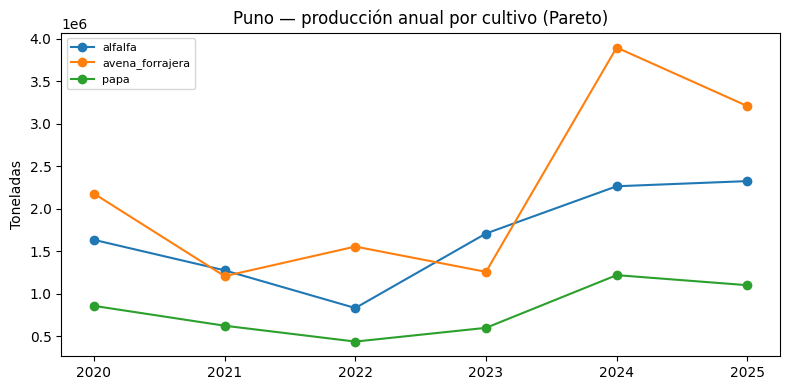

In [3]:
# =============================================================================
# CELDA 3 — Caso Puno: producción anual desagregada por cultivo
# =============================================================================
# Propósito:
#   Visualizar la evolución interanual de cada cultivo Pareto en Puno para
#   complementar el caso sequía del notebook 04 con granularidad por cultivo
#   (papa, quinua, alfalfa, etc.) — análisis descriptivo sin test formal.
# Sección del análisis: Análisis B — caso de estudio Puno / sequía 2022.
# Salidas esperadas:
#   - Figura: OUTPUTS/figures/eda_puno_produccion_anual.png
# =============================================================================

puno = df[df["region"] == "Puno"].copy()
if not puno.empty:
    idx = puno.groupby(["cultivo", "anio"])["produccion_ton"].sum(min_count=1).reset_index()
    fig, ax = plt.subplots(figsize=(8, 4))
    for cultivo, g in idx.groupby("cultivo"):
        ax.plot(g["anio"], g["produccion_ton"], marker="o", label=cultivo)
    ax.set_title("Puno — producción anual por cultivo (Pareto)")
    ax.set_ylabel("Toneladas")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(RUTA_FIGURES / "eda_puno_produccion_anual.png", dpi=150, bbox_inches="tight")
    plt.show()


### Interpretación — Puno por cultivo (`eda_puno_produccion_anual.png`)

- Una línea por cultivo Pareto en Puno (papa, quinua, alfalfa, etc.).
- Caídas pronunciadas en **2022** en cultivos andinos son el sustento cuantitativo del caso sequía del paper (ej. quinua, oca, papa según cifras del informe).
- Cultivos forrajeros o de menor sensibilidad hídrica pueden mostrar caídas menores → heterogeneidad intra-regional.
- Sin área cosechada no distinguimos si la caída es por menor rendimiento o menor superficie.